# Basic workflow with ART for evasion attacks and defences

In this notebook we will show
- how to work with a Keras image classifier in ART
- how ART abstracts from the specific ML/DL backend
- how to apply a Projected Gradient Descent (PGD) evasion attack against that classifier
- how to deploy defences against such attacks
- how to create adversarial samples that can bypass those defences

Added by Ed Herranz (10/15/2022):
- how to protect against a white box attack agsint the defences

## Install and load prerequisites

You can preinstall all prerequisites by uncommenting and running the following cell.

In [54]:

!pip install adversarial-robustness-toolbox


In [55]:


# Load basic dependencies:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
import matplotlib.pyplot as plt
import sys
import numpy as np

# Disable TensorFlow eager execution:
import tensorflow as tf
#if tf.executing_eagerly():
#    tf.compat.v1.disable_eager_execution()

# Load Keras dependencies:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.utils import load_img, img_to_array

# Load ART dependencies:
from art.estimators.classification import KerasClassifier
from art.attacks.evasion import ProjectedGradientDescent
from art.defences.preprocessor import SpatialSmoothing
from art.utils import to_categorical

# Install ImageNet stubs:
!{sys.executable} -m pip install git+https://github.com/nottombrown/imagenet_stubs
import imagenet_stubs
from imagenet_stubs.imagenet_2012_labels import name_to_label, label_to_name


  Cloning https://github.com/nottombrown/imagenet_stubs to /tmp/pip-req-build-43tf0t7y
  Running command git clone --filter=blob:none --quiet https://github.com/nottombrown/imagenet_stubs /tmp/pip-req-build-43tf0t7y
  Resolved https://github.com/nottombrown/imagenet_stubs to commit 0b501276f54cbf45b8e1b67dccbdcbe51de88365
  Preparing metadata (setup.py) ... done


## Load images

We are going to load a set of 16 example images for illustration purposes.

In [56]:
images_list = list()
for i, image_path in enumerate(imagenet_stubs.get_image_paths()):
    im = load_img(image_path, target_size=(224, 224))
    im = img_to_array(im)
    images_list.append(im)
    print(image_path)
    if 'gazelle.jpg' in image_path:
        # get unicycle index
        gazelle_idx = i
images = np.array(images_list)


/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/rock_crab.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/notebook_computer.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/koala.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/beagle.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/marmoset.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/tractor.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/sleeping_bag.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/bagel.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/malamute.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/standard_poodle.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/gazelle.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/manhole_cover.jpg
/usr/local/lib/python3.12/dist-packages/imagenet_stubs/images/mitten.jpg
/usr/local/

The images all have a resolution of 224 x 224 pixels, and 3 color channels (RGB).

In [57]:
print('Number of images:', images.shape[0])
print('Dimension of images:', images.shape[1], 'x', images.shape[2], 'pixels')
print('Number of color channels:', images.shape[3], '(RGB)')


Number of images: 16
Dimension of images: 224 x 224 pixels
Number of color channels: 3 (RGB)


As default choice, we are going to use the unicycle image for illustration purposes. But you could use any other of the 16 images in the following (just change the value of the `idx` variable).

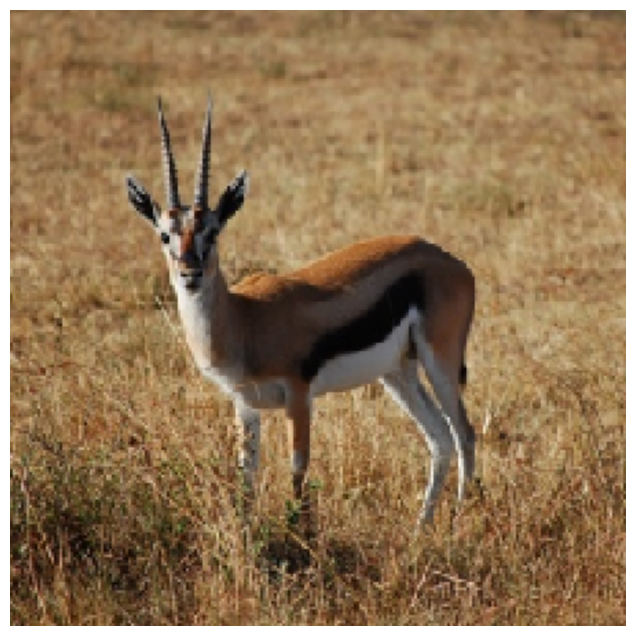

In [58]:
idx = gazelle_idx

plt.figure(figsize=(8,8)); plt.imshow(images[idx] / 255); plt.axis('off'); plt.show()


## Load ResNet50 classifier

Next we are going to use a state-of-the-art classifier on those images.

In [59]:
# This loads the pretrained ResNet50 model:
model = ResNet50(weights='imagenet')


In [60]:
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.SGD(),
)

Let's look at the prediction that this model yields for the selected image:

In [61]:
# We need to expand the input dimension and apply the preprocessing required for ResNet50:
x = np.expand_dims(images[idx].copy(), axis=0)
x = preprocess_input(x)

# Then apply the model, determine the predicted label and confidence:
pred = model.predict(x)
label = np.argmax(pred, axis=1)[0]
confidence = pred[:,label][0]

print('Prediction:', label_to_name(label), '- confidence {0:.2f}'.format(confidence))


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction: gazelle - confidence 1.00


So the model correctly tells us that this image shows a unicycle/monocycle, which is good :-)

Next we will create an ART KerasClassifier wrapper around the model. <br>
We need to take care of the `preprocess_input` logic that has to be applied:

- swap the order of the color channels (RGB -> BGR)
- subtract the channel means

In [62]:
from art.preprocessing.preprocessing import Preprocessor

class ResNet50Preprocessor(Preprocessor):

    def __call__(self, x, y=None):
        return preprocess_input(x.copy()), y

    def estimate_gradient(self, x, gradient):
        return gradient[..., ::-1]


In [63]:
# Create the ART preprocessor and classifier wrapper:
preprocessor = ResNet50Preprocessor()
loss_object = tf.keras.losses.CategoricalCrossentropy()
classifier = KerasClassifier(clip_values=(0, 255), model=model, preprocessing=preprocessor)


Now we will apply the classifier object to obtain the prediction.

**Note:** we have to swap the color channel order (from RGB to BGR) before feeding the input to the classifier

In [64]:
# Same as for the original model, we expand the dimension of the inputs.
x_art = np.expand_dims(images[idx], axis=0)

# Then apply the model through the classifier API, determine the predicted label and confidence:
pred = classifier.predict(x_art)
label = np.argmax(pred, axis=1)[0]
confidence = pred[:,label][0]

print('Prediction:', label_to_name(label), '- confidence {0:.2f}'.format(confidence))


Prediction: gazelle - confidence 1.00


So through the classifier API we obtain the same predictions as from the raw model, but now we have an abstraction from the actual backend (e.g. Keras).

The classifier wrapper allows us to call other functions besides predict.

For example, we can obtain the **loss gradient** of the classifier, which is used in many of the algorithms for adversarial sample generation:

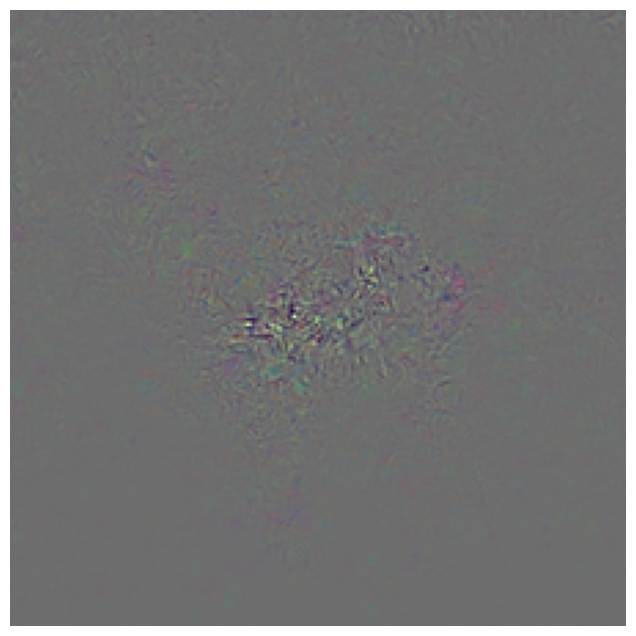

In [65]:
loss_gradient = classifier.loss_gradient(x=x_art, y=to_categorical([label], nb_classes=1000))

# Let's plot the loss gradient.
# First, swap color channels back to RGB order:
loss_gradient_plot = loss_gradient[0]

# Then normalize loss gradient values to be in [0,1]:
loss_gradient_min = np.min(loss_gradient)
loss_gradient_max = np.max(loss_gradient)
loss_gradient_plot = (loss_gradient_plot - loss_gradient_min)/(loss_gradient_max - loss_gradient_min)

# Show plot:
plt.figure(figsize=(8,8)); plt.imshow(loss_gradient_plot); plt.axis('off'); plt.show()


## Create adversarial samples

Next, we are going to create an adversarial sample. <br>
We are going to use **Projected Gradient Descent (PGD)**, which is one of the strongest existing attacks. <br>
We will first perform an **untargeted** adversarial attack.

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/10 [00:00<?, ?it/s]

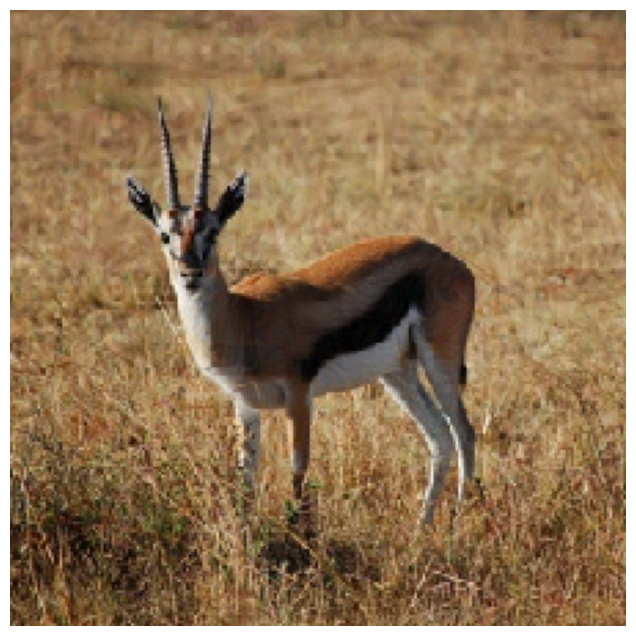

Prediction: impala, Aepyceros melampus - confidence 1.00


In [66]:
# Create the attacker:
adv = ProjectedGradientDescent(classifier, targeted=False, max_iter=10, eps_step=1, eps=5)

# Generate the adversarial sample:
x_art_adv = adv.generate(x_art)

# Plot the adversarial sample (note: we swap color channels back to RGB order):
plt.figure(figsize=(8,8)); plt.imshow(x_art_adv[0] / 255); plt.axis('off'); plt.show()

# And apply the classifier to it:
pred_adv = classifier.predict(x_art_adv)
label_adv = np.argmax(pred_adv, axis=1)[0]
confidence_adv = pred_adv[:, label_adv][0]
print('Prediction:', label_to_name(label_adv), '- confidence {0:.2f}'.format(confidence_adv))


Next, we will perform a **targeted attack** where we pick the class that we want the classifier to predict on the adversarial sample. <br>
Below is the list of labels and class names - make your pick!

In [67]:
for i in range(1000):
    print('label', i, '-', label_to_name(i))


label 0 - tench, Tinca tinca
label 1 - goldfish, Carassius auratus
label 2 - great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias
label 3 - tiger shark, Galeocerdo cuvieri
label 4 - hammerhead, hammerhead shark
label 5 - electric ray, crampfish, numbfish, torpedo
label 6 - stingray
label 7 - cock
label 8 - hen
label 9 - ostrich, Struthio camelus
label 10 - brambling, Fringilla montifringilla
label 11 - goldfinch, Carduelis carduelis
label 12 - house finch, linnet, Carpodacus mexicanus
label 13 - junco, snowbird
label 14 - indigo bunting, indigo finch, indigo bird, Passerina cyanea
label 15 - robin, American robin, Turdus migratorius
label 16 - bulbul
label 17 - jay
label 18 - magpie
label 19 - chickadee
label 20 - water ouzel, dipper
label 21 - kite
label 22 - bald eagle, American eagle, Haliaeetus leucocephalus
label 23 - vulture
label 24 - great grey owl, great gray owl, Strix nebulosa
label 25 - European fire salamander, Salamandra salamandra
label 26 

As default, let's get this image misclassified as black swan (label 100)!

In [68]:
target_label = 100


Now let's perform the targeted attack:

In [69]:
to_categorical([target_label])

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1.]], dtype=float32)

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/10 [00:00<?, ?it/s]

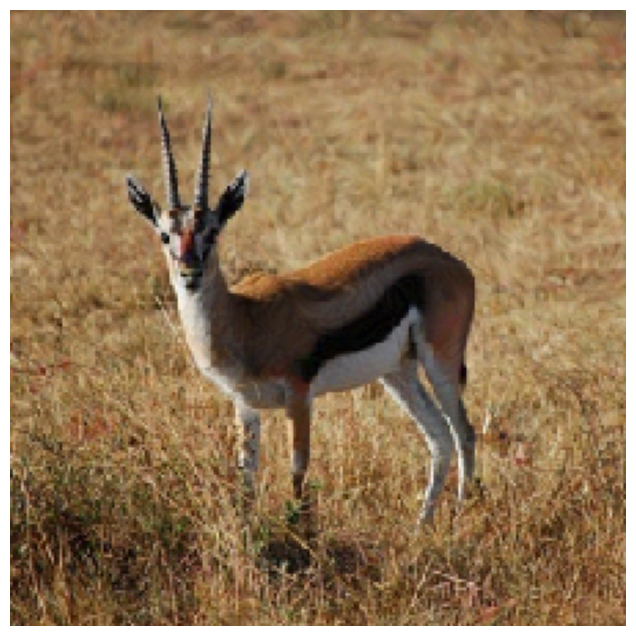

Prediction: black swan, Cygnus atratus - confidence 1.00


In [70]:
# Set the configuration to a targeted attack:
adv.set_params(targeted=True)

# Generate the adversarial sample:
x_art_adv = adv.generate(x_art, y=to_categorical([target_label], nb_classes=classifier.nb_classes))

# Plot the adversarial sample (note: we swap color channels back to RGB order):
plt.figure(figsize=(8,8)); plt.imshow(x_art_adv[0] / 255); plt.axis('off'); plt.show()

# And apply the classifier to it:
pred_adv = classifier.predict(x_art_adv)
label_adv = np.argmax(pred_adv, axis=1)[0]
confidence_adv = pred_adv[:, label_adv][0]
print('Prediction:', label_to_name(label_adv), '- confidence {0:.2f}'.format(confidence_adv))


We can measure the quantity of perturbation that was added to the image using different $\ell_p$ norms. <br>
**Note:** the PGD attack controls the $\ell_\infty$ norm via the `epsilon` parameter.

Perturbation l_0 norm: 81%
Perturbation l_1 norm: 3%
Perturbation l_2 norm: 3%
Noise l_inf norm: 2%


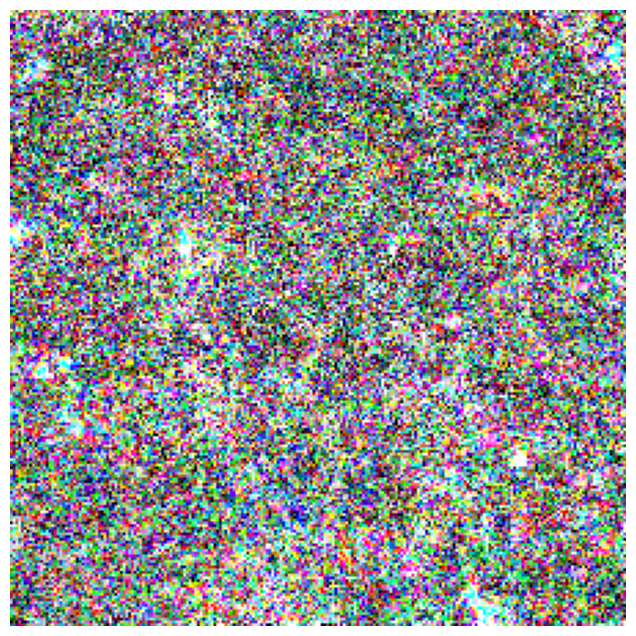

In [71]:
l_0 = int(99*len(np.where(np.abs(x_art[0] - x_art_adv[0])>0.5)[0]) / (224*224*3)) + 1
l_1 = int(99*np.sum(np.abs(x_art[0] - x_art_adv[0])) / np.sum(np.abs(x_art[0]))) + 1
l_2 = int(99*np.linalg.norm(x_art[0] - x_art_adv[0]) / np.linalg.norm(x_art[0])) + 1
l_inf = int(99*np.max(np.abs(x_art[0] - x_art_adv[0])) / 255) + 1

print('Perturbation l_0 norm: %d%%' % l_0)
print('Perturbation l_1 norm: %d%%' % l_1)
print('Perturbation l_2 norm: %d%%' % l_2)
print('Noise l_inf norm: %d%%' % l_inf)

# Let's also plot the absolute amount of adversarial pixel perturbations:
pert = np.abs(x_art[0] - x_art_adv[0])[..., ::-1]
pert_min = np.min(pert)
pert_max = np.max(pert)
plt.figure(figsize=(8,8)); plt.imshow((pert - pert_min) / (pert_max - pert_min)); plt.axis('off'); plt.show()


## Apply defences

Next we are going to apply a simple input preprocessing defence: Spatial Smoothing. <br>
Ideally, we want this defence to result in correct predictions when applied both to the original and the adversarial images.

In [72]:
import pandas as pd

results = []

for w in range(3, 11):
    # Initialize Spatial Smoothing with current window size
    ss = SpatialSmoothing(window_size=w)

    # Apply defense
    x_def, _ = ss(x_art)
    x_adv_def, _ = ss(x_art_adv)

    # Predictions on original sample
    pred_def = classifier.predict(x_def)
    label_def = np.argmax(pred_def, axis=1)[0]
    conf_def = pred_def[0, label_def]

    # Predictions on adversarial sample
    pred_adv_def = classifier.predict(x_adv_def)
    label_adv_def = np.argmax(pred_adv_def, axis=1)[0]
    conf_adv_def = pred_adv_def[0, label_adv_def]

    # Store results
    results.append({
        "Window Size": w,
        "Original Prediction": label_to_name(label_def),
        "Original Confidence": conf_def,
        "Adversarial Prediction": label_to_name(label_adv_def),
        "Adversarial Confidence": conf_adv_def
    })


In [73]:
df_results = pd.DataFrame(results)
df_results["Original Confidence"] = df_results["Original Confidence"].round(2)
df_results["Adversarial Confidence"] = df_results["Adversarial Confidence"].round(2)
print(df_results.to_string(index=False))

 Window Size Original Prediction  Original Confidence Adversarial Prediction  Adversarial Confidence
           3             gazelle                  1.0                gazelle                    0.96
           4             gazelle                  1.0                gazelle                    0.99
           5             gazelle                  1.0                gazelle                    0.99
           6             gazelle                  1.0                gazelle                    0.99
           7             gazelle                  1.0                gazelle                    1.00
           8             gazelle                  1.0                gazelle                    1.00
           9             gazelle                  1.0                gazelle                    1.00
          10             gazelle                  1.0                gazelle                    0.99


## Perform adaptive whitebox attack to defeat defences

Next we are going to mount an adaptive whitebox attack in which the attacker aims at defeating the defence that we just put into place.

First, we create a classifier which incorporates the defence:

In [74]:
classifier_def = KerasClassifier(preprocessing=preprocessor, preprocessing_defences=[ss], clip_values=(0, 255),
                                 model=model)

# Now we apply this classifier to the adversarial sample from before:
pred_def = classifier_def.predict(x_art_adv)
label_def = np.argmax(pred_def, axis=1)[0]
confidence_def = pred_def[:, label_def][0]

print('Prediction:', label_to_name(label_def), '- confidence {0:.2f}'.format(confidence_def))



Prediction: gazelle - confidence 0.99


We observe that this classifier reproduces the prediction that we had obtained before by manually applying the input preprocessing defence.

Now we create an adversarial sample against the *defended* classifier. <br>
As we are going to see, this adversarial sample is able to bypass the input preprocessing defence.

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

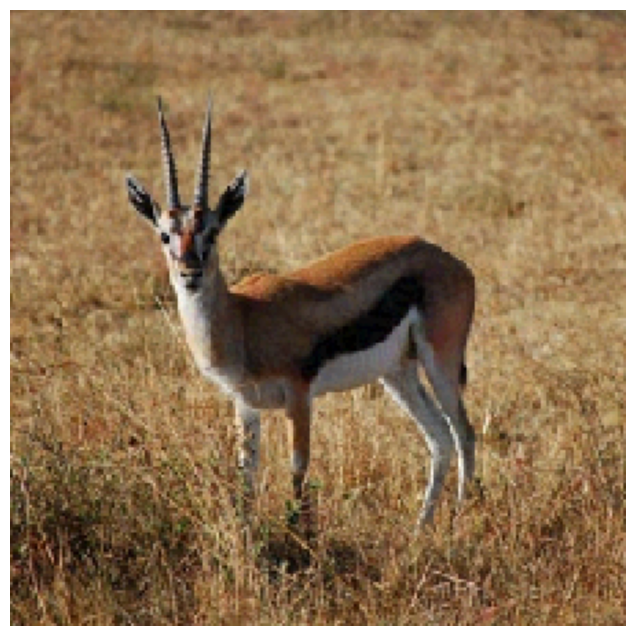

Prediction: crane - confidence 0.20


In [75]:
# Create the attacker.
# Note: here we use a larger number of iterations to achieve the same level of confidence in the misclassification
adv_def = ProjectedGradientDescent(classifier_def, targeted=True, max_iter=40, eps_step=1, eps=5)

# Generate the adversarial sample:
x_art_adv_def = adv_def.generate(x_art, y=to_categorical([target_label], nb_classes=classifier.nb_classes))

# Plot the adversarial sample (note: we swap color channels back to RGB order):
plt.figure(figsize=(8,8)); plt.imshow(x_art_adv_def[0] / 255); plt.axis('off'); plt.show()

# And apply the classifier to it:
pred_adv = classifier_def.predict(x_art_adv_def)
label_adv = np.argmax(pred_adv, axis=1)[0]
confidence_adv = pred_adv[:, label_adv][0]
print('Prediction:', label_to_name(label_adv), '- confidence {0:.2f}'.format(confidence_adv))


Let's also look at the $\ell_p$ norms of that adversarial perturbation:

In [76]:
l_0 = int(99*len(np.where(np.abs(x_art[0] - x_art_adv_def[0])>0.5)[0]) / (224*224*3)) + 1
l_1 = int(99*np.sum(np.abs(x_art[0] - x_art_adv_def[0])) / np.sum(np.abs(x_art[0]))) + 1
l_2 = int(99*np.linalg.norm(x_art[0] - x_art_adv_def[0]) / np.linalg.norm(x_art[0])) + 1
l_inf = int(99*np.max(np.abs(x_art[0] - x_art_adv_def[0])) / 255) + 1

print('Perturbation l_0 norm: %d%%' % l_0)
print('Perturbation l_1 norm: %d%%' % l_1)
print('Perturbation l_2 norm: %d%%' % l_2)
print('Noise l_inf norm: %d%%' % l_inf)


Perturbation l_0 norm: 96%
Perturbation l_1 norm: 4%
Perturbation l_2 norm: 4%
Noise l_inf norm: 2%


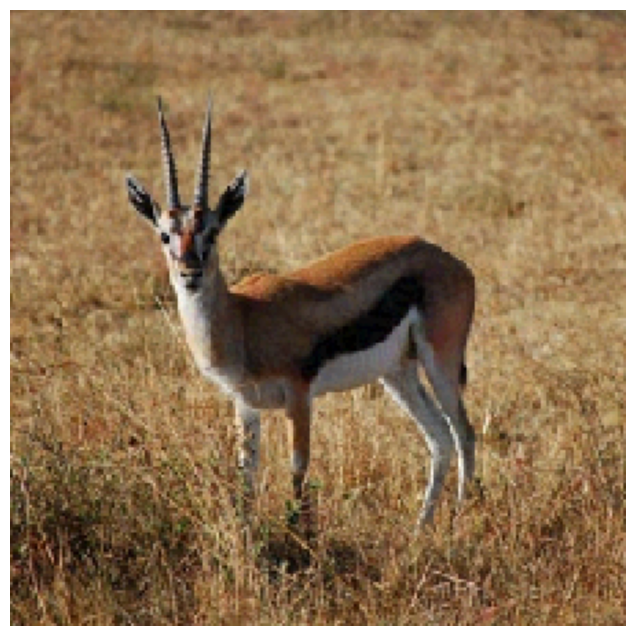

Prediction of whitebox adversarial attacked image with GaussiaNoise Post Processing: gazelle - confidence 0.01
Prediction of original image with GaussianNoise Post Processing: gazelle - confidence 0.01
Prediction of whitebox adversarial attacked image with JpegCompression Pre-Processing: gazelle - confidence 1.00
Prediction of original image with JpegCompression Pre-Processing gazelle - confidence 1.00


In [77]:
#This part was added by Ed Herranz to see if we can defend against the whitebox attack to defeat defences

from art.defences.postprocessor import GaussianNoise
from art.defences.preprocessor import JpegCompression

plt.figure(figsize=(8,8)); plt.imshow(x_art_adv_def[0] / 255); plt.axis('off'); plt.show()


classifier_def1 = KerasClassifier(preprocessing=preprocessor,  postprocessing_defences=GaussianNoise(scale=0.35), clip_values=(0, 255),
                               model=model)

#notice the GaussianNoise post-processing predicts the wrong class for the  whitebox adversarial attacked image
pred_adv = classifier_def1.predict(x_art_adv_def)
label_adv = np.argmax(pred_adv, axis=1)[0]
confidence_adv = pred_adv[:, label_adv][0]
print('Prediction of whitebox adversarial attacked image with GaussiaNoise Post Processing:', label_to_name(label_adv), '- confidence {0:.2f}'.format(confidence_adv))


#notice the GaussianNoise post-processing predicts the wrong class for the  original image
pred_adv = classifier_def1.predict(x_art)
label_adv = np.argmax(pred_adv, axis=1)[0]
confidence_adv = pred_adv[:, label_adv][0]
print('Prediction of original image with GaussianNoise Post Processing:', label_to_name(label_adv), '- confidence {0:.2f}'.format(confidence_adv))

classifier_def2 = KerasClassifier(preprocessing=preprocessor, preprocessing_defences=JpegCompression(quality=50,clip_values=(0, 255)), clip_values=(0, 255),
                                 model=model)

#notice the JpegCompression pre-processing predicts the correct class for the  whitebox adversarial attacked image
pred_adv = classifier_def2.predict(x_art_adv_def)
label_adv = np.argmax(pred_adv, axis=1)[0]
confidence_adv = pred_adv[:, label_adv][0]
print('Prediction of whitebox adversarial attacked image with JpegCompression Pre-Processing:', label_to_name(label_adv), '- confidence {0:.2f}'.format(confidence_adv))

#notice the JpegCompression pre-processing predicts the correct class for the original image
pred_adv = classifier_def2.predict(x_art)
label_adv = np.argmax(pred_adv, axis=1)[0]
confidence_adv = pred_adv[:, label_adv][0]
print('Prediction of original image with JpegCompression Pre-Processing', label_to_name(label_adv), '- confidence {0:.2f}'.format(confidence_adv))



In [78]:
import pandas as pd
import numpy as np

jpeg_results = []

for q in range(20, 95, 5):  # 20 to 90 inclusive
    classifier_jpeg = KerasClassifier(
        preprocessing=preprocessor,
        preprocessing_defences=JpegCompression(quality=q, clip_values=(0, 255)),
        clip_values=(0, 255),
        model=model
    )

    # Original image
    pred_orig = classifier_jpeg.predict(x_art)
    label_orig = np.argmax(pred_orig, axis=1)[0]
    conf_orig = pred_orig[0, label_orig]

    # Adversarial image
    pred_adv = classifier_jpeg.predict(x_art_adv_def)
    label_adv = np.argmax(pred_adv, axis=1)[0]
    conf_adv = pred_adv[0, label_adv]

    jpeg_results.append({
        "JPEG Quality": q,
        "Original Prediction": label_to_name(label_orig),
        "Original Confidence": conf_orig,
        "Adversarial Prediction": label_to_name(label_adv),
        "Adversarial Confidence": conf_adv
    })

df_jpeg = pd.DataFrame(jpeg_results)
df_jpeg["Original Confidence"] = df_jpeg["Original Confidence"].round(2)
df_jpeg["Adversarial Confidence"] = df_jpeg["Adversarial Confidence"].round(2)

print(df_jpeg.to_string(index=False))


 JPEG Quality Original Prediction  Original Confidence Adversarial Prediction  Adversarial Confidence
           20             gazelle                  1.0                gazelle                    1.00
           25             gazelle                  1.0                gazelle                    1.00
           30             gazelle                  1.0                gazelle                    1.00
           35             gazelle                  1.0                gazelle                    1.00
           40             gazelle                  1.0                gazelle                    1.00
           45             gazelle                  1.0                gazelle                    1.00
           50             gazelle                  1.0                gazelle                    1.00
           55             gazelle                  1.0                gazelle                    1.00
           60             gazelle                  1.0                gazelle     

In [79]:
gaussian_results = []

for s in np.arange(0.05, 1.55, 0.10):
    classifier_gauss = KerasClassifier(
        preprocessing=preprocessor,
        postprocessing_defences=GaussianNoise(scale=s),
        clip_values=(0, 255),
        model=model
    )

    # Original image
    pred_orig = classifier_gauss.predict(x_art)
    label_orig = np.argmax(pred_orig, axis=1)[0]
    conf_orig = pred_orig[0, label_orig]

    # Adversarial image
    pred_adv = classifier_gauss.predict(x_art_adv_def)
    label_adv = np.argmax(pred_adv, axis=1)[0]
    conf_adv = pred_adv[0, label_adv]

    gaussian_results.append({
        "Gaussian Scale": round(s, 2),
        "Original Prediction": label_to_name(label_orig),
        "Original Confidence": conf_orig,
        "Adversarial Prediction": label_to_name(label_adv),
        "Adversarial Confidence": conf_adv
    })

df_gauss = pd.DataFrame(gaussian_results)
df_gauss["Original Confidence"] = df_gauss["Original Confidence"].round(2)
df_gauss["Adversarial Confidence"] = df_gauss["Adversarial Confidence"].round(2)

print(df_gauss.to_string(index=False))


 Gaussian Scale                                  Original Prediction  Original Confidence                                            Adversarial Prediction  Adversarial Confidence
           0.05                                              gazelle                 0.05                                                           gazelle                    0.05
           0.15                                              gazelle                 0.01                                                           gazelle                    0.02
           0.25                                              gazelle                 0.01                                                           gazelle                    0.01
           0.35                       Pembroke, Pembroke Welsh corgi                 0.01                                                            pillow                    0.01
           0.45                                              gazelle                 0.01           

Comparing with the previous adversarial sample, the $\ell_0$ and $\ell_1$ norms have slightly increased, while $\ell_2$ and $\ell_\infty$ norms have stayed the same (the latter not being surprising as the PGD attack controls the $\ell_\infty$ norm budget).

In [80]:
from art.defences.preprocessor import FeatureSqueezing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fs_results = []

for b in [1, 2, 3, 4]:
    fs = FeatureSqueezing(bit_depth=b, clip_values=(0, 255))

    # Apply defense to original + adversarial
    x_fs, _ = fs(x_art)
    x_adv_fs, _ = fs(x_art_adv)

    # Predict on defended original
    pred_fs = classifier.predict(x_fs)
    label_fs = np.argmax(pred_fs, axis=1)[0]
    conf_fs = pred_fs[0, label_fs]

    # Predict on defended adversarial
    pred_adv_fs = classifier.predict(x_adv_fs)
    label_adv_fs = np.argmax(pred_adv_fs, axis=1)[0]
    conf_adv_fs = pred_adv_fs[0, label_adv_fs]

    fs_results.append({
        "Bit Depth": b,
        "Original Prediction": label_to_name(label_fs),
        "Original Confidence": conf_fs,
        "Adversarial Prediction": label_to_name(label_adv_fs),
        "Adversarial Confidence": conf_adv_fs
    })

df_fs = pd.DataFrame(fs_results)
df_fs["Original Confidence"] = df_fs["Original Confidence"].round(2)
df_fs["Adversarial Confidence"] = df_fs["Adversarial Confidence"].round(2)

print(df_fs.to_string(index=False))


 Bit Depth    Original Prediction  Original Confidence     Adversarial Prediction  Adversarial Confidence
         1 fire screen, fireguard                 0.56     fire screen, fireguard                    0.74
         2                gazelle                 0.98                    gazelle                    0.78
         3                gazelle                 1.00                      crane                    0.24
         4                gazelle                 1.00 black swan, Cygnus atratus                    1.00


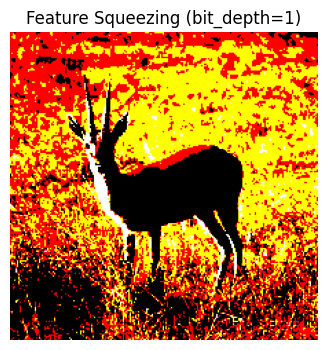

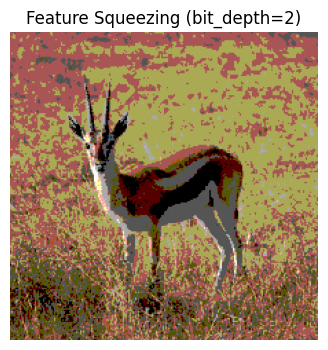

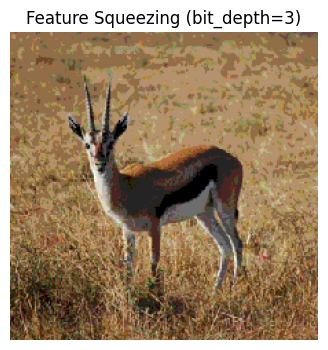

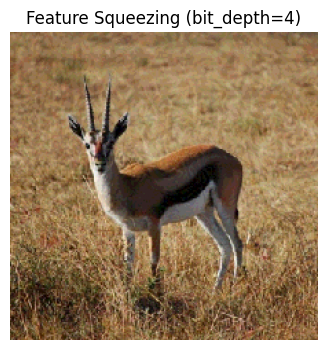

In [81]:
for b in [1, 2, 3, 4]:
    fs = FeatureSqueezing(bit_depth=b, clip_values=(0, 255))
    x_adv_fs, _ = fs(x_art_adv)

    plt.figure(figsize=(4,4))
    plt.imshow(x_adv_fs[0] / 255)
    plt.axis("off")
    plt.title(f"Feature Squeezing (bit_depth={b})")
    plt.show()


## Conclusions

We have walked through an end-to-end example of using a Keras image classifier in ART, creating adversarial samples, deploying input preprocessing defences and, finally, bypassing those defences in an adaptive white-box attack.